### 1) Import Pandas and Numpy

In [63]:
import pandas as pd
import numpy as np

### 2) Import the dataset and  Assign it to a variable called Chipo

#### Import the dataset from
https://github.com/justmarkham/pandas-videos/blob/master/data/chipotle.tsv

#### REMEMBER: It is a .tsv file , you will have to do some research on how to read .tsv files first!

In [64]:
url='https://raw.githubusercontent.com/justmarkham/pandas-videos/master/data/chipotle.tsv'
chipo=pd.read_csv(url,sep='\t')

### 3) See the first 10 entries

In [65]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### 4) What is the number of observations in the dataset?

In [66]:
print(len(chipo))

4622


### 5) What is the number of columns in the dataset?

In [67]:
print(chipo.shape[1])

5


### 6) Print the name of all the columns.

In [68]:
print(chipo.columns)

Index(['order_id', 'quantity', 'item_name', 'choice_description',
       'item_price'],
      dtype='object')


### 7) Which was the most-ordered item?

In [69]:
fen = chipo.groupby('item_name').sum(numeric_only=True)
fen = fen.sort_values(['quantity'], ascending=False)
fen.head(1)

,order_id,quantity
item_name,,
Chicken Bowl,713926,761


### 8) For the most-ordered item, how many items were ordered?

In [70]:
fen.head(1)['quantity']

,quantity
item_name,
Chicken Bowl,761


### 9) What was the most ordered item in the choice_description column?

In [71]:
fun=chipo.groupby('choice_description').sum(numeric_only=True)
fun=fun.sort_values(['quantity'],ascending=False)
fun.head(1)

,order_id,quantity
choice_description,,
[Diet Coke],123455,159


### 10) How many items were ordered in total?

In [72]:
total=chipo['quantity'].sum()
print(total)

4972


### 11) Turn the item price into a float

In [73]:
chipo['item_price']=chipo['item_price'].str.replace('$','').astype(float)
print(chipo['item_price'].dtype)

float64


### 12) How much was the revenue for the period in the dataset?
#### Revenue will be the sum of quantity * item_price!

In [74]:
tot=(chipo['quantity']*chipo['item_price']).sum()
print(round(tot,2))

39237.02


### 13) How many orders were made in the period?

In [75]:
all = chipo['order_id'].nunique()
print(all)

1834


### 14) What is the average revenue amount per order?

In [76]:
chipo['revenue']=chipo['quantity']*chipo['item_price']
avg=chipo.groupby('order_id')['revenue'].sum().mean()
print(round(avg,2))

21.39


### 15) How many different items are sold?

In [77]:
func=chipo['item_name'].unique()
print(len(func))

50


### 16) Show a histogram with number of orders with bill on the x-axis.

[]

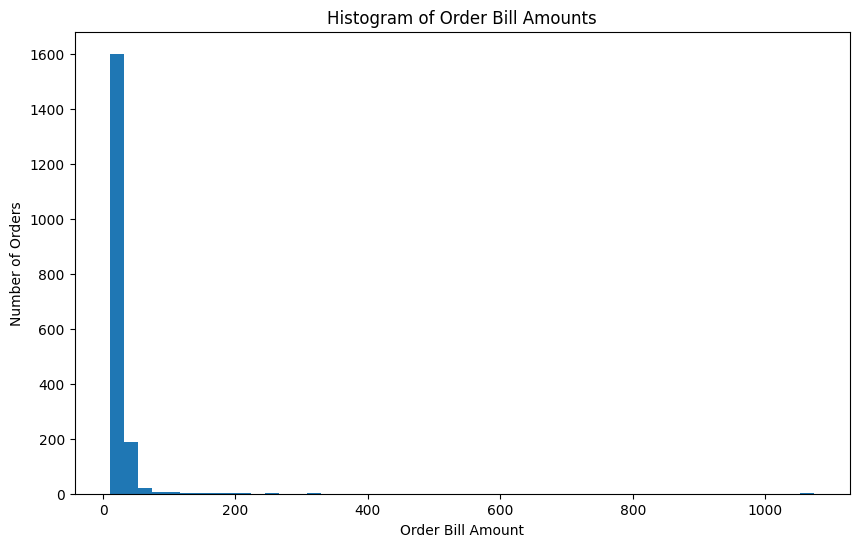

In [78]:
import matplotlib.pyplot as plt
order=chipo.groupby('order_id')['revenue'].sum()
plt.figure(figsize=(10,6))
plt.hist(order, bins=50)
plt.xlabel('Order Bill Amount')
plt.ylabel('Number of Orders')
plt.title('Histogram of Order Bill Amounts')
plt.plot()